<a href="https://colab.research.google.com/github/juanepstein99/DI_Bootcamp/blob/main/Week14/Day2/MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Mini Project — Apple (AAPL) Stock Analysis

### Dataset
**Apple Stock Prices from 1981 to 2023**

This notebook analyzes Apple stock prices using **Pandas, Matplotlib, SciPy and NumPy**.

The project covers:

1. Data Loading and Exploration  
2. Data Visualization  
3. Statistical Analysis  
4. Hypothesis Testing  
5. Advanced Statistical Techniques (Bonus)  
   - Signal Processing using SciPy  
   - Statistical Functions in NumPy  
6. Summary and Insights  
7. Reflection  

---

### Dataset columns

- **Date** — Trading date
- **Open** — Opening stock price
- **High** — Highest price during the trading day
- **Low** — Lowest price during the trading day
- **Close** — Closing stock price
- **Adj Close** — Closing price adjusted for corporate actions such as stock splits and dividends
- **Volume** — Number of shares traded

> The code is written specifically for the dataset provided with this project.

## 0. Setup

First, import the libraries that will be used throughout the notebook.

We will use:

- **Pandas** for loading and manipulating the dataset
- **NumPy** for numerical and statistical operations
- **Matplotlib** for charts
- **SciPy** for statistical tests and signal processing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy import stats
from scipy.signal import savgol_filter

# Makes tables easier to read in Colab
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Data Loading and Exploration

## 1.1 Upload and load the dataset

The original project file is provided as a `.zip`, so this cell accepts either:

- the original ZIP file, or
- the extracted CSV file.

If a ZIP is uploaded, the notebook automatically extracts the CSV inside it.

In [2]:
from google.colab import files
import zipfile
import os

# Upload the project dataset from your computer
uploaded = files.upload()

uploaded_file = list(uploaded.keys())[0]

# If the uploaded file is a ZIP, extract it and locate the CSV
if uploaded_file.lower().endswith('.zip'):
    with zipfile.ZipFile(uploaded_file, 'r') as zip_ref:
        zip_ref.extractall('/content/aapl_data')

    csv_files = [
        os.path.join('/content/aapl_data', file)
        for file in os.listdir('/content/aapl_data')
        if file.lower().endswith('.csv')
    ]

    file_path = csv_files[0]

# If the user uploaded the CSV directly, use it as-is
else:
    file_path = uploaded_file

df = pd.read_csv(file_path)

print(f"Loaded file: {file_path}")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")

Saving Apple Stock Prices From 1981 to 2023.zip to Apple Stock Prices From 1981 to 2023.zip
Loaded file: /content/aapl_data/Apple Stock Prices (1981 to 2023).csv
Dataset shape: 10608 rows × 7 columns


In [3]:
# Display the first 5 rows
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,02/01/1981,0.1540,0.1551,0.1540,0.1540,0.1198,21660800
1,05/01/1981,0.1512,0.1512,0.1507,0.1507,0.1172,35728000
2,06/01/1981,0.1445,0.1445,0.1440,0.1440,0.1120,45158400
3,07/01/1981,0.1384,0.1384,0.1378,0.1378,0.1073,55686400
4,08/01/1981,0.1356,0.1356,0.1350,0.1350,0.1051,39827200


### Initial observation

The dataset contains **10,608 trading-day observations** and **7 original columns**.

The prices are already numeric, while `Date` initially loads as text, so we will convert it to a proper datetime type.

## 1.2 Inspect data types and missing values

In [4]:
print("DATA TYPES")
print("-" * 40)
print(df.dtypes)

print("\nMISSING VALUES")
print("-" * 40)
print(df.isnull().sum())

DATA TYPES
----------------------------------------
Date          object
Open         float64
High         float64
Low          float64
Close        float64
Adj Close    float64
Volume         int64
dtype: object

MISSING VALUES
----------------------------------------
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


### Finding

The provided dataset contains **no null values** in its original columns.

This is useful because we do not need to impute or remove missing stock-price observations before performing the main analysis.

## 1.3 Clean and prepare the date column

The dates use **day/month/year** format, so `dayfirst=True` is important.

After conversion, the dataset is sorted chronologically.

In [5]:
# Remove accidental spaces from column names, if any
df.columns = df.columns.str.strip()

# Convert Date from text to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Sort from oldest to newest
df = df.sort_values('Date').reset_index(drop=True)

# Add useful time-based columns
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.to_period('M').astype(str)

print("First date:", df['Date'].min().date())
print("Last date: ", df['Date'].max().date())
print("Number of rows:", len(df))

First date: 1981-01-02
Last date:  2023-01-27
Number of rows: 10608


### Finding

The dataset runs from **January 2, 1981 to January 27, 2023**.

Because the final year only includes January observations, **2023 is a partial year**. This will matter later when comparing years statistically.

## 1.4 Check duplicate dates

In [6]:
duplicate_dates = df['Date'].duplicated().sum()
print("Duplicate trading dates:", duplicate_dates)

Duplicate trading dates: 0


## 1.5 Examine time-series frequency

Stock exchanges do not trade every calendar day.

We therefore expect:

- mostly 1-day gaps between consecutive trading sessions,
- larger gaps around weekends,
- occasional larger gaps because of market holidays.

In [7]:
date_gaps = df['Date'].diff().dropna()

print("Most common gaps between observations:")
display(date_gaps.value_counts().head(10))

print("Median gap:", date_gaps.median())

Most common gaps between observations:


,count
Date,
1 days,8317
3 days,1927
4 days,265
2 days,95
5 days,2
7 days,1


Median gap: 1 days 00:00:00


In [8]:
# Number of observations per year
year_counts = df.groupby('Year').size()

display(year_counts.head())
display(year_counts.tail())

,0
Year,
1981,253
1982,253
1983,253
1984,253
1985,252


,0
Year,
2019,252
2020,253
2021,252
2022,251
2023,18


### Time-series interpretation

The data behaves like a **daily financial time series based on trading days**, rather than a continuous calendar-day series.

That means weekends and holidays naturally create gaps. This is expected and should not be treated as missing data.

## 1.6 Quick trend inspection

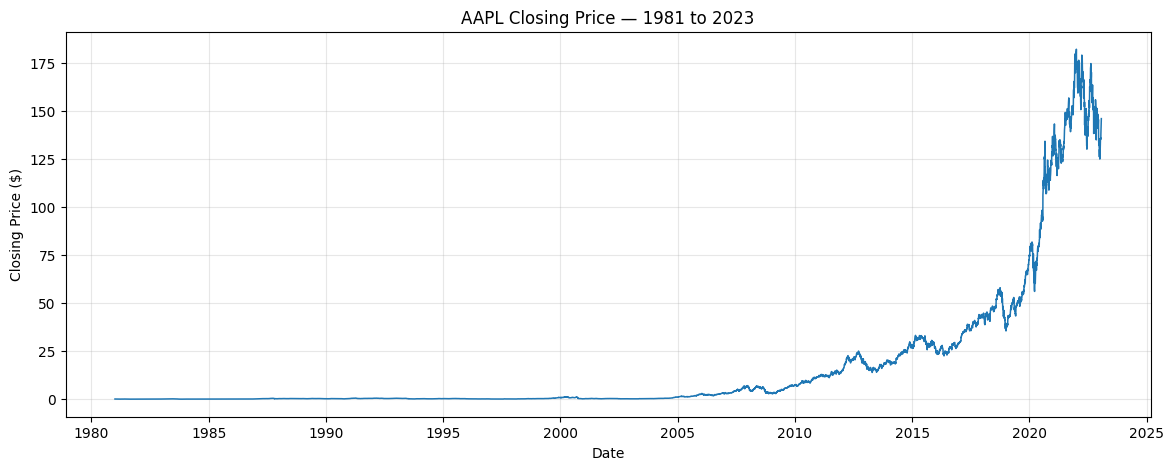

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], linewidth=1.1)

plt.title('AAPL Closing Price — 1981 to 2023')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.grid(alpha=0.3)
plt.show()

### Trend finding

The chart shows a very strong long-term upward trend in Apple's stock price, especially from the 2000s onward.

The early part of the series appears compressed because Apple's historical prices were much smaller than its more recent prices.

# 2. Data Visualization

## 2.1 Closing price over time

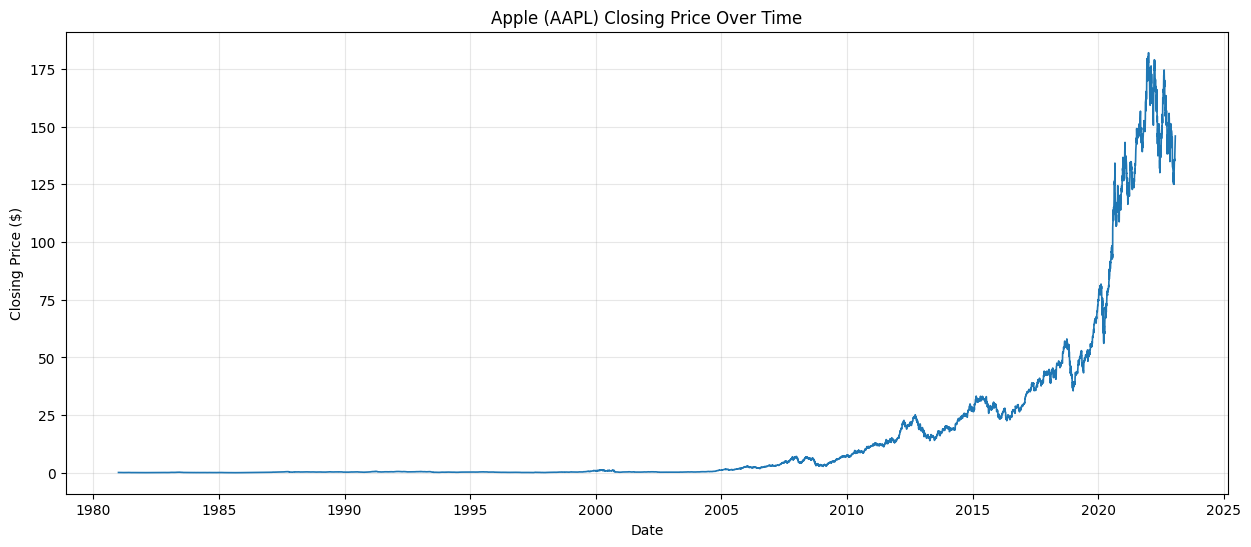

In [10]:
plt.figure(figsize=(15, 6))
plt.plot(df['Date'], df['Close'], linewidth=1.2)

plt.title('Apple (AAPL) Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price ($)')
plt.grid(alpha=0.3)
plt.show()

## 2.2 Trading volume over time

Trading volume measures the number of shares traded during each session.

Large volume spikes may indicate periods of unusually high investor activity.

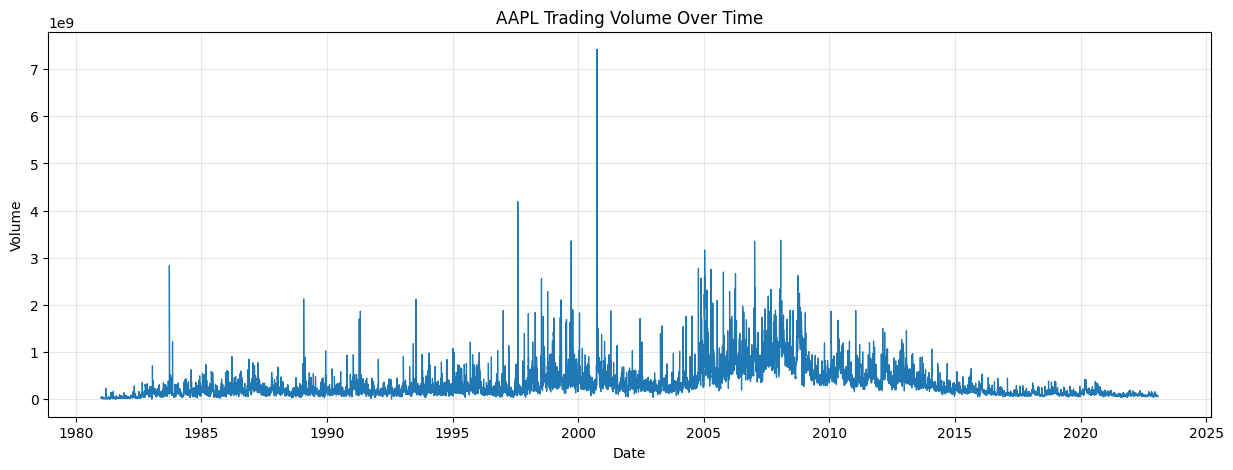

In [11]:
plt.figure(figsize=(15, 5))
plt.plot(df['Date'], df['Volume'], linewidth=0.9)

plt.title('AAPL Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.grid(alpha=0.3)
plt.show()

### Visualization finding

Volume is much more irregular than price.

There are many sharp spikes, showing that trading activity can change dramatically from one period to another.

## 2.3 Candlestick chart

A candlestick contains four price values:

- **Open**
- **High**
- **Low**
- **Close**

The wick shows the daily high-to-low price range.

Because more than 10,000 candlesticks would be impossible to read clearly, we will plot the **latest 90 trading days**.

In [12]:
# mplfinance is a convenient library for financial candlestick charts
!pip -q install mplfinance

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 3.4 MB/s eta 0:00:00


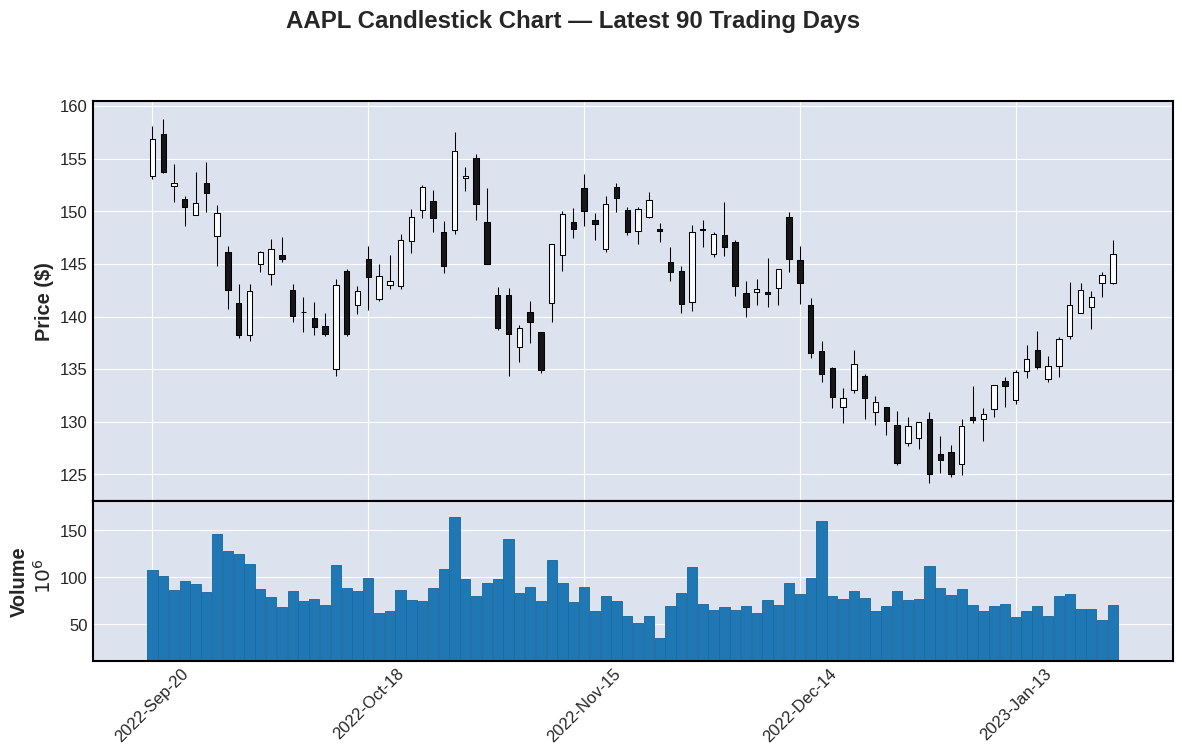

In [13]:
import mplfinance as mpf

candlestick_df = df[
    ['Date', 'Open', 'High', 'Low', 'Close', 'Volume']
].copy()

candlestick_df = candlestick_df.set_index('Date')

# Use only the last 90 sessions so individual candles remain readable
recent_90 = candlestick_df.tail(90)

mpf.plot(
    recent_90,
    type='candle',
    volume=True,
    title='AAPL Candlestick Chart — Latest 90 Trading Days',
    ylabel='Price ($)',
    ylabel_lower='Volume',
    figsize=(15, 8)
)

### Candlestick interpretation

The candlestick chart helps identify:

- daily price ranges,
- sessions that closed above or below their opening price,
- periods with larger intraday volatility,
- relationships between price movement and trading volume.

# 3. Statistical Analysis

## 3.1 Summary statistics

We calculate the **mean, median and standard deviation** for the main numerical columns.

### Meaning of each statistic

- **Mean:** arithmetic average
- **Median:** middle observation; less sensitive to extreme values
- **Standard deviation:** measures dispersion around the mean

In [14]:
key_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

summary_stats = pd.DataFrame({
    'Mean': df[key_columns].mean(),
    'Median': df[key_columns].median(),
    'Standard Deviation': df[key_columns].std()
})

summary_stats

,Mean,Median,Standard Deviation
Open,16.6892,0.4888,35.4505
High,16.8800,0.4955,35.8828
Low,16.5008,0.4804,35.0313
Close,16.6974,0.4877,35.4739
Adj Close,16.0273,0.4049,35.1549
Volume,"327,509,817.2606","214,597,600.0000","337,820,279.0577"


### Summary-statistics findings

For `Close`:

- Mean closing price is approximately **$16.70**
- Median closing price is approximately **$0.49**
- Standard deviation is approximately **$35.47**

The large difference between the mean and median is caused by Apple's enormous long-term price growth. Most early historical observations are very small compared with recent prices.

For `Volume`, the standard deviation is also very large, confirming substantial variation in daily trading activity.

## 3.2 Moving averages

A moving average smooths short-term fluctuations and makes the underlying price trend easier to see.

We calculate:

- **20-day moving average** → roughly one trading month
- **50-day moving average** → medium-term trend
- **200-day moving average** → long-term trend

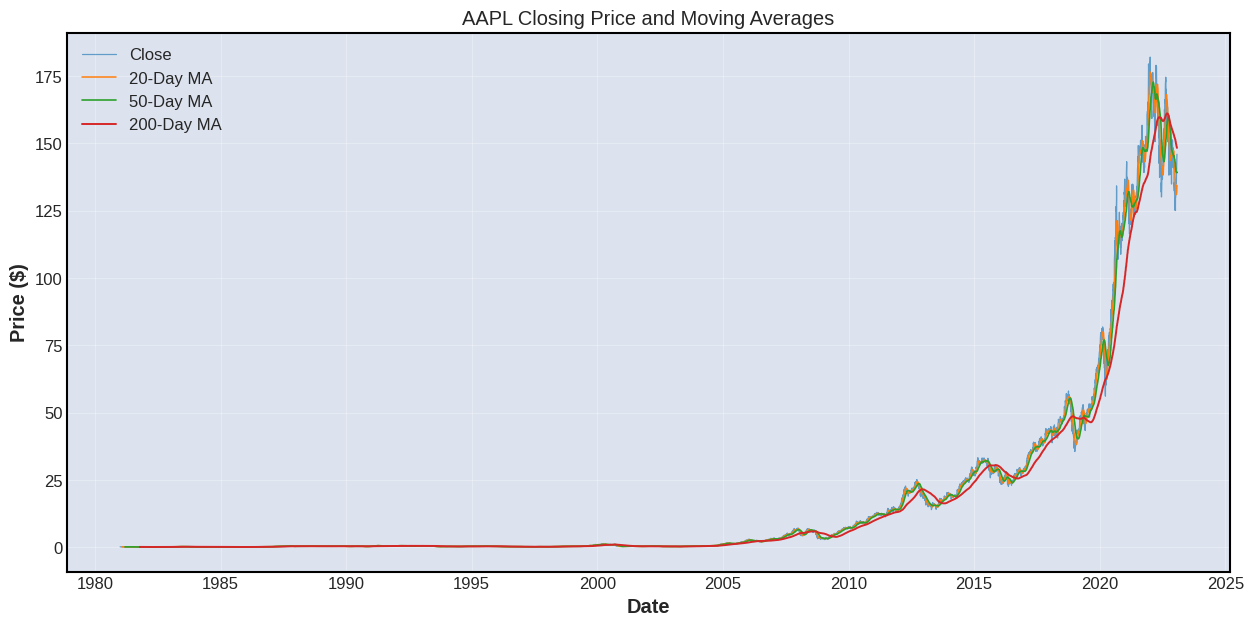

In [15]:
df['MA_20'] = df['Close'].rolling(window=20).mean()
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(15, 7))

plt.plot(df['Date'], df['Close'],
         label='Close', linewidth=0.9, alpha=0.65)

plt.plot(df['Date'], df['MA_20'],
         label='20-Day MA', linewidth=1.1)

plt.plot(df['Date'], df['MA_50'],
         label='50-Day MA', linewidth=1.2)

plt.plot(df['Date'], df['MA_200'],
         label='200-Day MA', linewidth=1.4)

plt.title('AAPL Closing Price and Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
# Inspect the most recent observation
latest = df.iloc[-1]

print("Latest date:", latest['Date'].date())
print(f"Latest Close: ${latest['Close']:.2f}")

for ma in ['MA_20', 'MA_50', 'MA_200']:
    value = latest[ma]

    if pd.notna(value):
        relationship = 'above' if latest['Close'] > value else 'below'
        print(f"{ma}: ${value:.2f} → Close is {relationship} the moving average")

Latest date: 2023-01-27
Latest Close: $145.93
MA_20: $134.39 → Close is above the moving average
MA_50: $139.11 → Close is above the moving average
MA_200: $148.29 → Close is below the moving average


### Moving-average interpretation

Short moving averages react more quickly to price changes, while long moving averages provide a smoother view of the overall trend.

The 200-day moving average is especially useful for identifying broader long-term direction, while the 20-day moving average tracks short-term changes more closely.

# 4. Hypothesis Testing

## 4.1 T-test comparing closing prices across years

We compare the **first year (1981)** with the **latest year (2023)**.

### Hypotheses

**H₀:** The mean closing price is equal in both years.

**H₁:** The mean closing price is different between the two years.

We use **Welch's independent t-test** because:

- the sample sizes are unequal,
- the price variances are very different,
- Welch's test does not assume equal variance.

Significance level:

**α = 0.05**

In [17]:
year_1 = df['Year'].min()
year_2 = df['Year'].max()

close_year_1 = df.loc[df['Year'] == year_1, 'Close'].dropna()
close_year_2 = df.loc[df['Year'] == year_2, 'Close'].dropna()

print(f"{year_1} observations:", len(close_year_1))
print(f"{year_2} observations:", len(close_year_2))

print(f"\nMean Close in {year_1}: ${close_year_1.mean():.4f}")
print(f"Mean Close in {year_2}: ${close_year_2.mean():.4f}")

1981 observations: 253
2023 observations: 18

Mean Close in 1981: $0.1085
Mean Close in 2023: $134.9050


In [18]:
t_stat, p_value = stats.ttest_ind(
    close_year_1,
    close_year_2,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10e}")

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject H0")
    print("The mean closing prices are statistically significantly different.")
else:
    print("\nDecision: Fail to reject H0")
    print("There is not enough evidence of a difference in mean closing prices.")

T-statistic: -89.2292
P-value: 3.7414135496e-24

Decision: Reject H0
The mean closing prices are statistically significantly different.


### T-test finding

The p-value is extremely small, far below **0.05**, so we reject the null hypothesis.

There is very strong statistical evidence that Apple's average closing price in 1981 differs from the average closing price in the available 2023 observations.

However, there are two important limitations:

1. **2023 contains only 18 trading observations** in this dataset.
2. Stock prices are time-series observations and successive prices are not perfectly independent.

Therefore, this test is useful for the project exercise, but it should not be interpreted as a complete financial model.

## 4.2 Calculate daily returns

A stock's daily return measures its percentage change from one trading session to the next.

\[
R_t = \frac{P_t-P_{t-1}}{P_{t-1}}
\]

Pandas provides this calculation using `pct_change()`.

In [19]:
df['Daily_Return'] = df['Close'].pct_change()

returns = df['Daily_Return'].dropna()

returns.describe()

,Daily_Return
count,"10,607.0000"
mean,0.0011
std,0.0282
min,-0.5187
25%,-0.0131
50%,0.0000
75%,0.0147
max,0.3323


In [20]:
print(f"Mean daily return: {returns.mean():.6f}")
print(f"Median daily return: {returns.median():.6f}")
print(f"Daily-return standard deviation: {returns.std():.6f}")

Mean daily return: 0.001052
Median daily return: 0.000000
Daily-return standard deviation: 0.028235


### Daily-return finding

The average daily return is close to zero, which is normal for daily financial data.

However, the standard deviation is much larger than the mean, showing that day-to-day movements are substantially more volatile than the average daily gain.

## 4.3 Distribution of daily returns

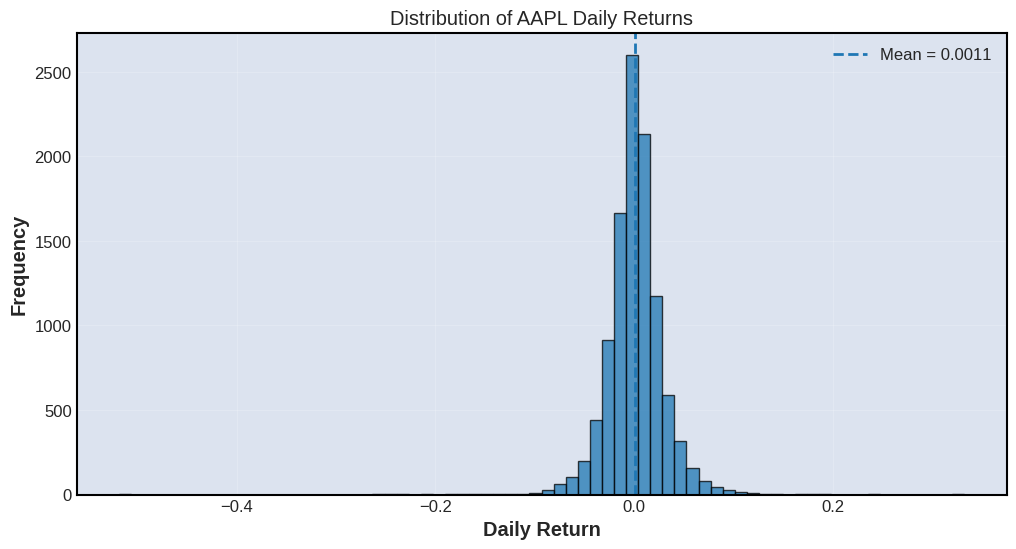

In [21]:
plt.figure(figsize=(12, 6))

plt.hist(returns, bins=70, edgecolor='black', alpha=0.75)

plt.axvline(
    returns.mean(),
    linestyle='--',
    label=f'Mean = {returns.mean():.4f}'
)

plt.title('Distribution of AAPL Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 4.4 Normality test using SciPy

We use **D'Agostino and Pearson's normality test**.

### Hypotheses

**H₀:** Daily returns follow a normal distribution.

**H₁:** Daily returns do not follow a normal distribution.

In [22]:
normality_stat, normality_p = stats.normaltest(returns)

print(f"Normality test statistic: {normality_stat:.4f}")
print(f"P-value: {normality_p:.10e}")

if normality_p < 0.05:
    print("\nDecision: Reject H0")
    print("Daily returns do NOT appear normally distributed.")
else:
    print("\nDecision: Fail to reject H0")
    print("There is not enough evidence to reject normality.")

Normality test statistic: 2719.2053
P-value: 0.0000000000e+00

Decision: Reject H0
Daily returns do NOT appear normally distributed.


### Normality finding

The normality-test p-value is effectively **0**, so we reject the null hypothesis.

This means Apple's daily returns in this dataset are **not normally distributed**.

To understand the shape in more detail, we also calculate skewness and kurtosis.

In [23]:
skewness = stats.skew(returns)
excess_kurtosis = stats.kurtosis(returns)

print(f"Skewness: {skewness:.4f}")
print(f"Excess kurtosis: {excess_kurtosis:.4f}")

Skewness: -0.3752
Excess kurtosis: 18.1252


### Distribution interpretation

For this dataset:

- Skewness is approximately **-0.38**, indicating slight negative skew.
- Excess kurtosis is approximately **18.13**, which is extremely high compared with a normal distribution.

This indicates **fat tails**, meaning unusually large daily movements occur more often than a normal-distribution assumption would predict.

This is an important concept in financial analysis because models based only on normality can underestimate extreme market risk.

# 5. Advanced Statistical Techniques — Bonus

## 5.1 NumPy moving average using `np.convolve`

`np.convolve()` can perform moving-average calculations using a simple signal-processing approach.

For a 20-day moving average, we create a kernel where each day has equal weight:

\[
\frac{1}{20}
\]

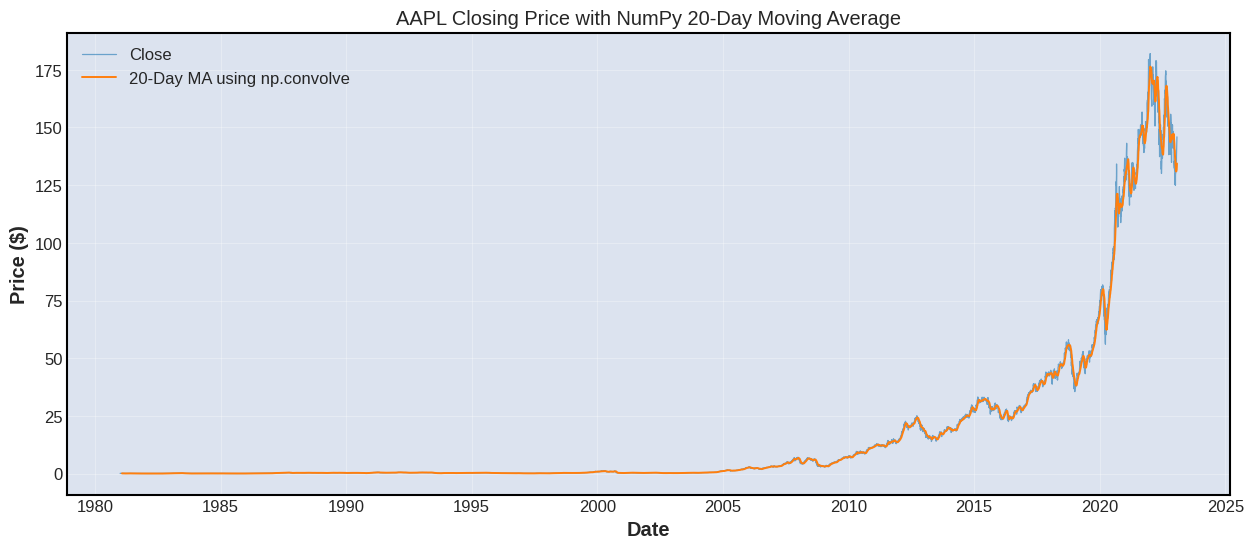

In [24]:
window = 20

close_values = df['Close'].to_numpy()

# Create 20 equal weights that sum to 1
kernel = np.ones(window) / window

# Calculate moving average
numpy_ma20 = np.convolve(close_values, kernel, mode='valid')

# Dates must begin after the first 19 observations
numpy_ma_dates = df['Date'].iloc[window - 1:]

plt.figure(figsize=(15, 6))

plt.plot(
    df['Date'],
    df['Close'],
    label='Close',
    linewidth=0.9,
    alpha=0.6
)

plt.plot(
    numpy_ma_dates,
    numpy_ma20,
    label='20-Day MA using np.convolve',
    linewidth=1.4
)

plt.title('AAPL Closing Price with NumPy 20-Day Moving Average')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Finding

The `np.convolve` moving average produces the same type of smoothing effect as Pandas' rolling mean.

This demonstrates how NumPy can perform signal-processing-style operations directly on numerical arrays.

## 5.2 Correlation matrix using NumPy

`np.corrcoef()` measures linear correlation.

Correlation values range between:

- **+1** → perfect positive relationship
- **0** → no linear relationship
- **-1** → perfect negative relationship

We will examine relationships among:

- Close
- High
- Low
- Open
- Volume

In [25]:
variables = ['Open', 'High', 'Low', 'Close', 'Volume']

corr_matrix = np.corrcoef(
    df[variables].to_numpy().T
)

corr_df = pd.DataFrame(
    corr_matrix,
    index=variables,
    columns=variables
)

corr_df

,Open,High,Low,Close,Volume
Open,1.0000,0.9999,0.9999,0.9998,-0.2148
High,0.9999,1.0000,0.9999,0.9999,-0.2142
Low,0.9999,0.9999,1.0000,0.9999,-0.2156
Close,0.9998,0.9999,0.9999,1.0000,-0.2149
Volume,-0.2148,-0.2142,-0.2156,-0.2149,1.0000


### Correlation interpretation

Open, High, Low and Close are expected to have extremely strong positive correlations because they all measure the stock's price during the same trading session.

Volume behaves differently because it measures **trading activity**, not price.

## 5.3 Correlation between closing price and trading volume

In [26]:
close_volume_corr = np.corrcoef(
    df['Close'],
    df['Volume']
)[0, 1]

print(f"Correlation between Close and Volume: {close_volume_corr:.4f}")

Correlation between Close and Volume: -0.2149


### Finding

The overall correlation between closing price and volume is approximately **-0.21**.

This represents a weak negative linear relationship across the full 1981–2023 period.

However, long historical periods can behave differently from one another, so this single coefficient should not be treated as proof that higher prices cause lower volume.

## 5.4 Correlations between moving averages and trading volume

The project specifically asks us to examine correlations between moving averages of closing prices and trading volume.

We compare:

- 20-day moving average vs Volume
- 50-day moving average vs Volume
- 200-day moving average vs Volume

In [27]:
moving_average_correlations = {}

for ma_column in ['MA_20', 'MA_50', 'MA_200']:

    temp = df[[ma_column, 'Volume']].dropna()

    correlation = np.corrcoef(
        temp[ma_column],
        temp['Volume']
    )[0, 1]

    moving_average_correlations[ma_column] = correlation

ma_corr_df = pd.DataFrame.from_dict(
    moving_average_correlations,
    orient='index',
    columns=['Correlation with Volume']
)

ma_corr_df

,Correlation with Volume
MA_20,-0.2147
MA_50,-0.2156
MA_200,-0.2233


### Moving-average correlation findings

The moving averages show weak negative correlations with trading volume:

- 20-day MA: approximately **-0.21**
- 50-day MA: approximately **-0.22**
- 200-day MA: approximately **-0.22**

The similarity among these coefficients suggests that changing the smoothing window does not radically change the overall historical relationship between Apple's price level and trading volume.

## 5.5 Correlation across different time periods

A single correlation across more than 40 years can hide changes over time.

To investigate this, we calculate the correlation between the **20-day moving average** and volume for each decade.

In [28]:
df['Decade'] = (df['Year'] // 10) * 10

decade_correlations = []

for decade, group in df.groupby('Decade'):

    clean_group = group[['MA_20', 'Volume']].dropna()

    if len(clean_group) > 1:
        corr = np.corrcoef(
            clean_group['MA_20'],
            clean_group['Volume']
        )[0, 1]

        decade_correlations.append({
            'Decade': decade,
            'MA20_vs_Volume_Correlation': corr,
            'Observations': len(clean_group)
        })

decade_corr_df = pd.DataFrame(decade_correlations)

decade_corr_df

,Decade,MA20_vs_Volume_Correlation,Observations
0,1980,0.1760,2256
1,1990,0.0453,2528
2,2000,0.4415,2515
3,2010,-0.6335,2516
4,2020,-0.5420,774


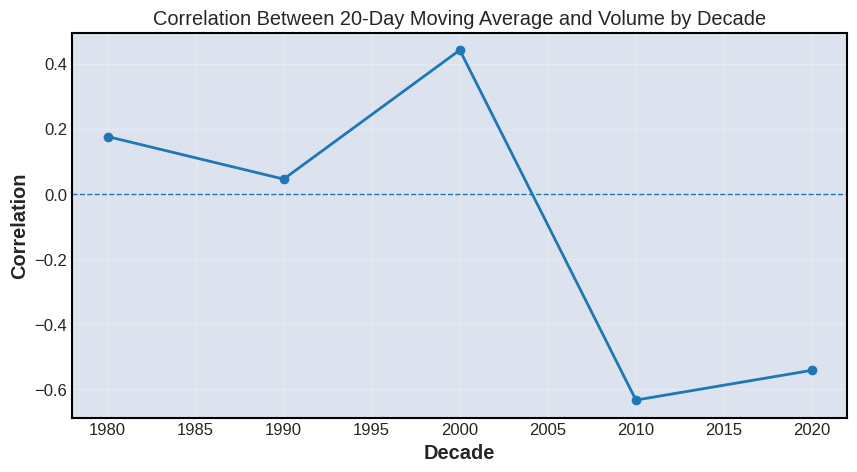

In [29]:
plt.figure(figsize=(10, 5))

plt.plot(
    decade_corr_df['Decade'],
    decade_corr_df['MA20_vs_Volume_Correlation'],
    marker='o'
)

plt.axhline(0, linestyle='--', linewidth=1)

plt.title('Correlation Between 20-Day Moving Average and Volume by Decade')
plt.xlabel('Decade')
plt.ylabel('Correlation')
plt.grid(alpha=0.3)
plt.show()

### Interpretation

Looking at separate decades is more informative than relying only on one global correlation coefficient.

Financial relationships are not necessarily stable across time. Market structure, Apple's size, stock splits, investor behavior and trading technology have all changed substantially since 1981.

# 5.6 Signal Processing using SciPy

The suggested project structure includes signal processing, so we use a **Savitzky–Golay filter** from SciPy.

Unlike a standard moving average, the Savitzky–Golay filter smooths a signal by fitting local polynomial curves.

This can preserve the overall shape of a trend while reducing short-term noise.

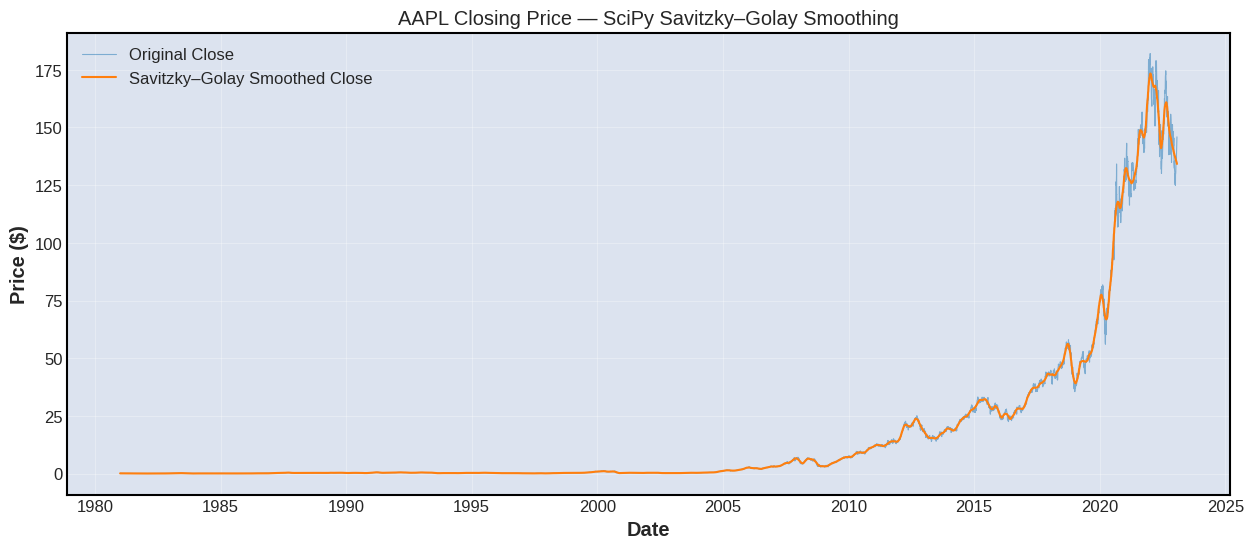

In [30]:
# Window length must be an odd number.
# 101 trading days is roughly 5 months of market sessions.
window_length = 101

# Polynomial order used for local smoothing
polyorder = 3

df['Close_Smoothed'] = savgol_filter(
    df['Close'],
    window_length=window_length,
    polyorder=polyorder
)

plt.figure(figsize=(15, 6))

plt.plot(
    df['Date'],
    df['Close'],
    label='Original Close',
    linewidth=0.8,
    alpha=0.5
)

plt.plot(
    df['Date'],
    df['Close_Smoothed'],
    label='Savitzky–Golay Smoothed Close',
    linewidth=1.5
)

plt.title('AAPL Closing Price — SciPy Savitzky–Golay Smoothing')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Signal-processing finding

The Savitzky–Golay filter reduces short-term noise while preserving the broad shape of Apple's historical price trend.

This makes long-term movements easier to observe without completely flattening local changes.

## 5.7 Optional: Rolling volatility

Although not explicitly required, daily-return volatility is an important financial statistic.

We calculate a **30-day rolling standard deviation** of daily returns.

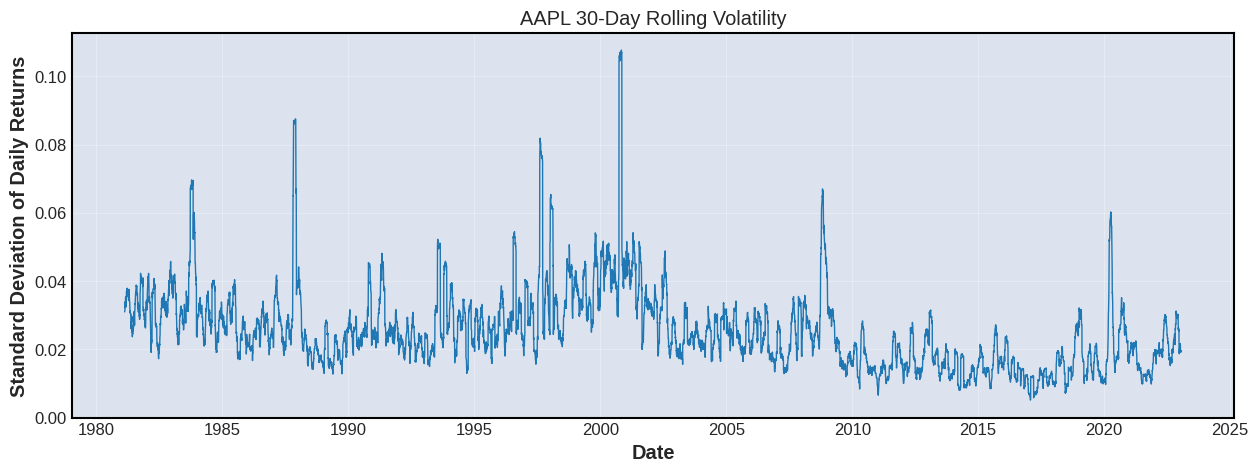

In [31]:
df['Rolling_Volatility_30'] = (
    df['Daily_Return']
    .rolling(window=30)
    .std()
)

plt.figure(figsize=(15, 5))

plt.plot(
    df['Date'],
    df['Rolling_Volatility_30'],
    linewidth=1
)

plt.title('AAPL 30-Day Rolling Volatility')
plt.xlabel('Date')
plt.ylabel('Standard Deviation of Daily Returns')
plt.grid(alpha=0.3)
plt.show()

### Volatility interpretation

Rolling volatility is not constant.

The chart shows periods in which Apple's daily returns became much more unstable than usual. This supports the idea that financial risk changes over time rather than remaining fixed.

# 6. Summary and Insights

This project analyzed **10,608 Apple trading-day observations from January 1981 to January 2023**.

### Main insights

**1. Strong long-term price growth**  
Apple's stock price shows a dramatic upward trend over the full dataset. The difference between the mean and median price reflects the very low historical price levels compared with recent decades.

**2. Trading volume is highly variable**  
Volume shows frequent spikes, indicating periods of unusually high market activity.

**3. Moving averages reveal trend more clearly**  
The 20-, 50- and 200-day moving averages reduce daily noise. Shorter moving averages react faster, while the 200-day average provides a smoother long-term view.

**4. Closing prices differ strongly across years**  
A Welch t-test comparing 1981 with the available 2023 data produced an extremely small p-value, leading us to reject the hypothesis of equal mean closing prices.

**5. Daily returns are not normally distributed**  
SciPy's normality test strongly rejects normality. The return series has slight negative skew and very high excess kurtosis, indicating fat tails and a higher frequency of extreme movements than a normal distribution predicts.

**6. Price and volume have only a weak overall relationship**  
The correlation between closing price and volume is roughly -0.21. Moving averages and volume show similar weak negative correlations.

**7. Correlations can change over time**  
Breaking the data into decades demonstrates why financial relationships should not automatically be assumed to remain constant over a 40+ year sample.

**8. Signal processing can help identify underlying trends**  
Both NumPy convolution and SciPy's Savitzky–Golay filter successfully smooth the price series and make broader patterns easier to identify.

### Final takeaway

The most important statistical insight is that stock-market data does not behave like a simple, stable normal process. Apple's price trend changes dramatically over time, volatility is dynamic, and daily returns contain unusually heavy tails. Therefore, statistical assumptions should always be checked before being used for financial interpretation.

# 7. Reflection

### Challenges

One challenge in this project was working with a dataset covering more than four decades. Apple's historical prices are extremely different from its recent prices, so graphs covering the complete period can visually compress early observations.

Another challenge was handling financial time-series data correctly. The dataset contains trading days rather than every calendar day, so weekend and holiday gaps are expected and should not be treated as missing observations.

The final year, 2023, also contains only a small number of observations. This makes the year-to-year t-test somewhat unbalanced and is important to mention when interpreting its result.

Daily stock returns presented another statistical challenge. A normal distribution might initially seem like a reasonable assumption, but the normality test and very high kurtosis showed that the actual return distribution contains much heavier tails.

### Solutions

To improve the analysis:

- Dates were parsed explicitly using `dayfirst=True`.
- The dataset was sorted chronologically before any time-series calculations.
- Moving averages were used to separate longer-term trends from daily price noise.
- Welch's t-test was used instead of the equal-variance version because the yearly samples differ substantially.
- SciPy's normality test, skewness and kurtosis were used together instead of relying only on a histogram.
- NumPy correlations were calculated not only globally but also across separate decades.
- A Savitzky–Golay filter was used as an additional signal-processing technique.

### What I learned

This project helped connect Python tools with real financial-data concepts. In particular, it demonstrated how Pandas is useful for time-series preparation, Matplotlib for visual exploration, SciPy for hypothesis testing and signal analysis, and NumPy for efficient numerical and correlation calculations.

It also reinforced that statistical significance and practical interpretation are not the same thing. A result can be highly significant while still requiring careful consideration of sample structure, time dependence and financial context.

---

## ✅ Project completed

The notebook contains:

- Data loading and cleaning
- Null-value and datatype checks
- Time-series exploration
- Closing-price visualization
- Volume visualization
- Candlestick chart
- Summary statistics
- Moving averages
- T-test
- Daily-return analysis
- Normality test
- Skewness and kurtosis
- NumPy `convolve`
- NumPy `corrcoef`
- Moving-average vs volume correlations
- Correlation analysis across time periods
- SciPy signal processing
- Rolling volatility
- Summary and insights
- Reflection